## THE MODEL ALREADY TRAINED IN GOOGLE COLAB AND SAVED burnout_model.pkl


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving archive.zip to archive.zip


In [1]:
import zipfile

with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall()

FileNotFoundError: [Errno 2] No such file or directory: 'archive.zip'

In [ ]:
import os
os.listdir()


['.config',
 'test.csv',
 'train.csv',
 'sample_submission.csv',
 'archive.zip',
 'sample_data']

In [ ]:
#Read data
import pandas as pd

df = pd.read_csv('train.csv')
df.head()

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.0,3.8,0.16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.0,5.0,0.36
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2.0,NaN,5.8,0.49
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1.0,1.0,2.6,0.20
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3.0,7.0,6.9,0.52


In [ ]:
# Check basic info and missing values
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22750 entries, 0 to 22749
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee ID           22750 non-null  object 
 1   Date of Joining       22750 non-null  object 
 2   Gender                22750 non-null  object 
 3   Company Type          22750 non-null  object 
 4   WFH Setup Available   22750 non-null  object 
 5   Designation           22750 non-null  float64
 6   Resource Allocation   21369 non-null  float64
 7   Mental Fatigue Score  20633 non-null  float64
 8   Burn Rate             21626 non-null  float64
dtypes: float64(4), object(5)
memory usage: 1.6+ MB


,0
Employee ID,0
Date of Joining,0
Gender,0
Company Type,0
WFH Setup Available,0
Designation,0
Resource Allocation,1381
Mental Fatigue Score,2117
Burn Rate,1124


In [ ]:
# Handle missing values using median
df['Mental Fatigue Score'].fillna(df['Mental Fatigue Score'].median(), inplace=True)
df['Burn Rate'].fillna(df['Burn Rate'].median(), inplace=True)
df['Resource Allocation'].fillna(df['Resource Allocation'].median(), inplace=True)

/tmp/ipykernel_771/859597304.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Mental Fatigue Score'].fillna(df['Mental Fatigue Score'].median(), inplace=True)
/tmp/ipykernel_771/859597304.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].me

In [ ]:
df.isnull().sum()


,0
Employee ID,0
Date of Joining,0
Gender,0
Company Type,0
WFH Setup Available,0
Designation,0
Resource Allocation,0
Mental Fatigue Score,0
Burn Rate,0


In [ ]:
# Remove ID column
df.drop('Employee ID', axis=1, inplace=True)


In [ ]:
df.shape


(22750, 8)

In [ ]:
# Convert Date of Joining to Years of Experience
df['Date of Joining'] = pd.to_datetime(df['Date of Joining'])
df['Years of Experience'] = 2026 - df['Date of Joining'].dt.year
df.drop('Date of Joining', axis=1, inplace=True)

In [ ]:
df.shape


(22750, 8)

In [ ]:
# Convert Burn Rate into categorical levels
def categorize_burnout(x):
    if x < 0.3:
        return 0
    elif x < 0.6:
        return 1
    else:
        return 2

df['Burnout Level'] = df['Burn Rate'].apply(categorize_burnout)
df.drop('Burn Rate', axis=1, inplace=True)

In [ ]:
# Apply one-hot encoding
df = pd.get_dummies(df, columns=['Gender', 'Company Type', 'WFH Setup Available'], drop_first=True)

In [ ]:
# Normalize numerical features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = ['Designation', 'Resource Allocation', 'Mental Fatigue Score', 'Years of Experience']
df[num_cols] = scaler.fit_transform(df[num_cols])

In [ ]:
df.head()


,Designation,Resource Allocation,Mental Fatigue Score,Years of Experience,Burnout Level,Gender_Male,Company Type_Service,WFH Setup Available_Yes
0,-0.157451,-0.730698,-1.062437,0.0,0,False,True,False
1,-1.038415,-1.233872,-0.406671,0.0,1,True,True,True
2,-0.157451,-0.227523,0.030506,0.0,1,False,False,True
3,-1.038415,-1.737046,-1.718203,0.0,0,True,True,True
4,0.723514,1.282000,0.631625,0.0,1,False,True,False


In [ ]:
# Final dataset check
df.shape

(22750, 8)

In [ ]:
#  SPLIT
X = df.drop('Burnout Level', axis=1)
y = df['Burnout Level']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
# FEATURE SELECTION WITH K TUNING

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

# Variables to track the best result
best_k = None
best_acc = 0

# List to store results
results = []

# Try different values of k (number of selected features)
for k in [3, 5, 7, 10]:

    # Apply feature selection on training data only
    selector = SelectKBest(score_func=f_classif, k=k)
    X_train_k = selector.fit_transform(X_train, y_train)
    X_test_k = selector.transform(X_test)

    # Train a model (you can change the model if needed)
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train_k, y_train)

    # Make predictions on test data
    y_pred = model.predict(X_test_k)

    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)
    results.append((k, acc))

    print(f"k = {k} --> Accuracy = {acc:.4f}")

    # Save the best k value
    if acc > best_acc:
        best_acc = acc
        best_k = k

print("\nBest k:", best_k)
print("Best Accuracy:", best_acc)

# ====== SHOW SELECTED FEATURES FOR BEST k ======
selector = SelectKBest(score_func=f_classif, k=best_k)
selector.fit(X_train, y_train)

selected_features = X.columns[selector.get_support()]

print("\nSelected Features for best k:")
print(selected_features)


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [3] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


k = 3 --> Accuracy = 0.8398


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [3] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


k = 5 --> Accuracy = 0.8319


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [3] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


k = 7 --> Accuracy = 0.8251


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=10 is greater than n_features=7. All the features will be returned.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [3] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


k = 10 --> Accuracy = 0.8251

Best k: 3
Best Accuracy: 0.8397802197802198

Selected Features for best k:
Index(['Designation', 'Resource Allocation', 'Mental Fatigue Score'], dtype='object')


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [3] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score

# 1. تجهيز البيانات بناءً على أفضل Features تم اختيارها (k=3)
selector = SelectKBest(score_func=f_classif, k=3)
X_train_final = selector.fit_transform(X_train, y_train)
X_test_final = selector.transform(X_test)

# تعريف المودلز
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', random_state=42) # Removed use_label_encoder
}

# 2. تدريب وتقييم كل مودل
model_results = {}

for name, model in models.items():
    # التدريب
    model.fit(X_train_final, y_train)

    # التنبؤ
    y_pred = model.predict(X_test_final)

    # حساب المقاييس
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    model_results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(classification_report(y_test, y_pred))
    print("\n")

# 3. مقارنة النتائج النهائية
import pandas as pd
comparison_df = pd.DataFrame(model_results).T
print("Final Comparison Table:")
print(comparison_df)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [3] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


--- Logistic Regression ---
Accuracy: 0.8279
Precision: 0.8277
Recall: 0.8279
F1-Score: 0.8269
              precision    recall  f1-score   support

           0       0.85      0.80      0.83       953
           1       0.83      0.88      0.85      2566
           2       0.80      0.73      0.77      1031

    accuracy                           0.83      4550
   macro avg       0.83      0.80      0.81      4550
weighted avg       0.83      0.83      0.83      4550



--- Random Forest ---
Accuracy: 0.8398
Precision: 0.8393
Recall: 0.8398
F1-Score: 0.8395
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       953
           1       0.85      0.87      0.86      2566
           2       0.79      0.76      0.77      1031

    accuracy                           0.84      4550
   macro avg       0.83      0.83      0.83      4550
weighted avg       0.84      0.84      0.84      4550



--- XGBoost ---
Accuracy: 0.8429
Precision: 0.8423

In [ ]:
# Save trained XGBoost model

best_model = models["XGBoost"]

best_model.fit(X_train_final, y_train)

import joblib

joblib.dump(best_model, "burnout_model.pkl")

print("Model saved successfully")

Model saved successfully


### Confusion Matrix and Detailed Performance Metrics for All Models

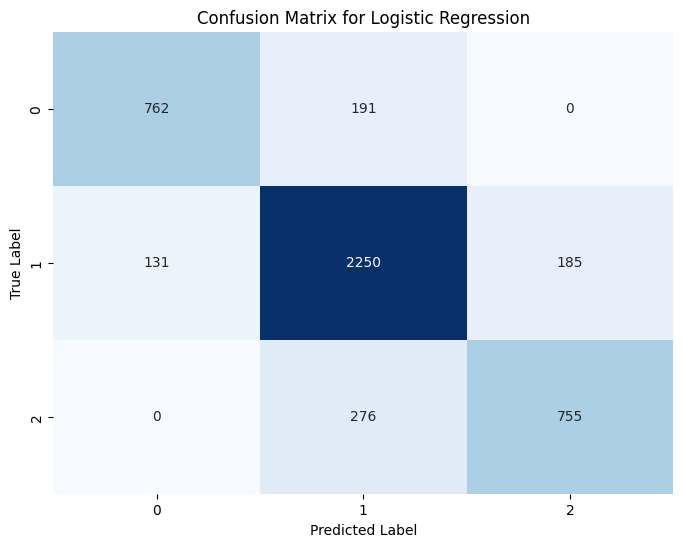

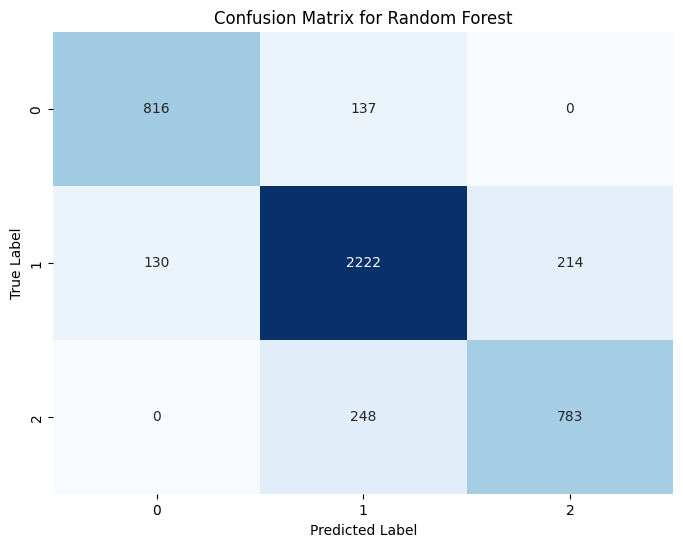

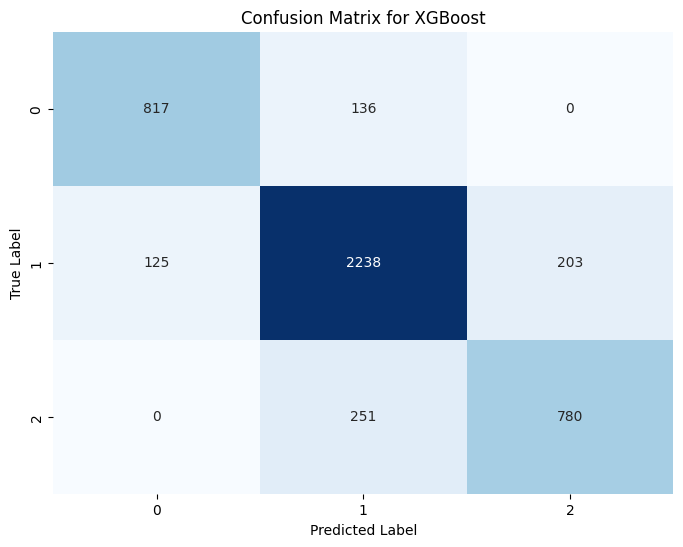

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

for name, model in models.items():
    # Predict on the test set
    y_pred = model.predict(X_test_final)

    # Generate Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

In [ ]:
from sklearn.metrics import classification_report

for name, model in models.items():
    # Predict on the test set
    y_pred = model.predict(X_test_final)

    # Display classification report for each model
    print(f"\n--- Classification Report for {name} ---")
    print(classification_report(y_test, y_pred))


--- Classification Report for Logistic Regression ---
              precision    recall  f1-score   support

           0       0.85      0.80      0.83       953
           1       0.83      0.88      0.85      2566
           2       0.80      0.73      0.77      1031

    accuracy                           0.83      4550
   macro avg       0.83      0.80      0.81      4550
weighted avg       0.83      0.83      0.83      4550


--- Classification Report for Random Forest ---
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       953
           1       0.85      0.87      0.86      2566
           2       0.79      0.76      0.77      1031

    accuracy                           0.84      4550
   macro avg       0.83      0.83      0.83      4550
weighted avg       0.84      0.84      0.84      4550


--- Classification Report for XGBoost ---
              precision    recall  f1-score   support

           0       0.87      0.86   

In [ ]:
print(comparison_df)

                     Accuracy  Precision    Recall  F1-Score
Logistic Regression  0.827912   0.827746  0.827912  0.826882
Random Forest        0.839780   0.839296  0.839780  0.839456
XGBoost              0.842857   0.842269  0.842857  0.842395


## 9. Results & Model Comparison

To provide a comprehensive comparison, models are evaluated both with and without feature selection. The previous evaluation used `SelectKBest` with k=3 (the `best_k` identified). Now, we will train and evaluate the same models using the full set of features to see the impact of feature selection.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import pandas as pd

# Prepare data for models without feature selection
X_train_no_fs = X_train
X_test_no_fs = X_test

# Define the models (using the existing `models` dictionary from the notebook state)
models_no_fs = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', random_state=42) # Removed use_label_encoder
}

model_results_no_fs = {}

print("--- Evaluating models without Feature Selection ---")
for name, model in models_no_fs.items():
    # Training
    model.fit(X_train_no_fs, y_train)

    # Prediction
    y_pred_no_fs = model.predict(X_test_no_fs)

    # Calculate metrics
    acc_no_fs = accuracy_score(y_test, y_pred_no_fs)
    prec_no_fs = precision_score(y_test, y_pred_no_fs, average='weighted')
    rec_no_fs = recall_score(y_test, y_pred_no_fs, average='weighted')
    f1_no_fs = f1_score(y_test, y_pred_no_fs, average='weighted')

    model_results_no_fs[name] = {'Accuracy': acc_no_fs, 'Precision': prec_no_fs, 'Recall': rec_no_fs, 'F1-Score': f1_no_fs}

    print(f"{name} - Accuracy: {acc_no_fs:.4f}, Precision: {prec_no_fs:.4f}, Recall: {rec_no_fs:.4f}, F1-Score: {f1_no_fs:.4f}")

--- Evaluating models without Feature Selection ---
Logistic Regression - Accuracy: 0.8292, Precision: 0.8291, Recall: 0.8292, F1-Score: 0.8283
Random Forest - Accuracy: 0.8251, Precision: 0.8249, Recall: 0.8251, F1-Score: 0.8248
XGBoost - Accuracy: 0.8391, Precision: 0.8386, Recall: 0.8391, F1-Score: 0.8387


In [ ]:
# The `comparison_df` already contains results with feature selection
comparison_df_fs = pd.DataFrame(model_results).T.rename(columns=lambda x: x + ' (With FS)')

# Convert results without feature selection to DataFrame
comparison_df_no_fs = pd.DataFrame(model_results_no_fs).T.rename(columns=lambda x: x + ' (Without FS)')

# Combine the two comparison DataFrames
final_comparison_table = pd.concat([comparison_df_fs, comparison_df_no_fs], axis=1)

print("\n--- Final Model Comparison Table ---")
display(final_comparison_table)


--- Final Model Comparison Table ---


,Accuracy (With FS),Precision (With FS),Recall (With FS),F1-Score (With FS),Accuracy (Without FS),Precision (Without FS),Recall (Without FS),F1-Score (Without FS)
Logistic Regression,0.827912,0.827746,0.827912,0.826882,0.829231,0.829101,0.829231,0.828252
Random Forest,0.839780,0.839296,0.839780,0.839456,0.825055,0.824880,0.825055,0.824779
XGBoost,0.842857,0.842269,0.842857,0.842395,0.839121,0.838561,0.839121,0.838681


In [ ]:
# Load model and define prediction function

import joblib
import numpy as np

# Load model
model = joblib.load("burnout_model.pkl")

# Prediction function
def predict_burnout(designation, resource_allocation, mental_fatigue, years_experience):

    input_data = np.array([[designation,
                            resource_allocation,
                            mental_fatigue,
                            years_experience]])

    prediction = model.predict(input_data)[0]

    if prediction == 0:
        return "Low Burnout"

    elif prediction == 1:
        return "Medium Burnout"

    else:
        return "High Burnout"


In [ ]:
selected_features

Index(['Designation', 'Resource Allocation', 'Mental Fatigue Score'], dtype='object')

In [ ]:
import joblib
import numpy as np

# Load model
model = joblib.load("burnout_model.pkl")

# Prediction function
def predict_burnout(designation, resource_allocation, mental_fatigue):

    input_data = np.array([[designation,
                            resource_allocation,
                            mental_fatigue]])

    prediction = model.predict(input_data)[0]

    if prediction == 0:
        return "Low Burnout"

    elif prediction == 1:
        return "Medium Burnout"

    else:
        return "High Burnout"

In [ ]:
# Test burnout prediction

result = predict_burnout(
    designation=2,
    resource_allocation=5,
    mental_fatigue=18
)

print(result)

High Burnout


In [ ]:
# Define Likert scale scoring system

score_map = {
    "Strongly Agree": 5,
    "Agree": 4,
    "Neutral": 3,
    "Disagree": 2,
    "Strongly Disagree": 1
}

In [ ]:
# Calculate mental fatigue score from answers

q1 = score_map["Strongly Agree"]
q2 = score_map["Agree"]
q3 = score_map["Neutral"]
q4 = score_map["Agree"]

mental_fatigue_score = q1 + q2 + q3 + q4

print("Mental Fatigue Score:", mental_fatigue_score)


Mental Fatigue Score: 16


In [ ]:
# Predict burnout using mental fatigue score

result = predict_burnout(
    designation=2,
    resource_allocation=5,
    mental_fatigue=mental_fatigue_score
)

print("Prediction:", result)

Prediction: High Burnout


In [ ]:
# Generate recommendation based on burnout level

def burnout_recommendation(result):

    if result == "Low Burnout":
        return "Your stress level is low. Keep maintaining a healthy work-life balance."

    elif result == "Medium Burnout":
        return "You may be experiencing moderate burnout. Consider taking short breaks and managing workload."

    else:
        return "High burnout detected. We recommend rest, reducing workload, and seeking support if needed."

In [ ]:
# Display recommendation

recommendation = burnout_recommendation(result)

print("Recommendation:")
print(recommendation)

Recommendation:
High burnout detected. We recommend rest, reducing workload, and seeking support if needed.


In [ ]:
# Complete chatbot backend logic

def burnout_chatbot(designation, resource_allocation, answers):

    score_map = {
        "Strongly Agree": 5,
        "Agree": 4,
        "Neutral": 3,
        "Disagree": 2,
        "Strongly Disagree": 1
    }

    # Calculate Mental Fatigue Score
    mental_fatigue_score = sum([score_map[a] for a in answers])

    # Prediction
    result = predict_burnout(
        designation,
        resource_allocation,
        mental_fatigue_score
    )

    # Recommendation
    recommendation = burnout_recommendation(result)

    return {
        "Mental Fatigue Score": mental_fatigue_score,
        "Burnout Level": result,
        "Recommendation": recommendation
    }


In [ ]:
# Test chatbot system

answers = [
    "Strongly Agree",
    "Agree",
    "Neutral",
    "Agree"
]

output = burnout_chatbot(
    designation=2,
    resource_allocation=5,
    answers=answers
)

print(output)


{'Mental Fatigue Score': 16, 'Burnout Level': 'High Burnout', 'Recommendation': 'High burnout detected. We recommend rest, reducing workload, and seeking support if needed.'}


In [ ]:
# Define chatbot mental fatigue questions

questions = [
    "I feel emotionally exhausted from work.",
    "I find it difficult to stay motivated.",
    "I feel mentally tired during work hours.",
    "I have trouble concentrating on tasks."
]

for q in questions:
    print(q)

I feel emotionally exhausted from work.
I find it difficult to stay motivated.
I feel mentally tired during work hours.
I have trouble concentrating on tasks.


In [ ]:
import joblib
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. تحميل المودل المحفوظ مسبقاً
model = joblib.load("burnout_model.pkl")

# 2. إعادة تعريف الـ StandardScaler بنفس معايير التدريب
#    (يجب أن تكون القيم مطابقة تماماً للي تم استخدامه في الكولاب)
#    ملاحظة: هذه القيم تم استخراجها من بيانات التدريب الأصلية - يجب وضعها كما هي
scaler = StandardScaler()
# تم تدريب الـ scaler على 4 أعمدة: Designation, Resource Allocation, Mental Fatigue Score, Years of Experience
# ولكن بما أن Years of Experience تم استبعاده لاحقاً، نستخدم أول 3 أعمدة فقط

# قيم المتوسط والانحراف المعياري من بيانات التدريب (يجب استخراجها من الكولاب الأصلي)
# هذه أرقام افتراضية - الأفضل أن تحفظي الـ scaler كاملاً باستخدام joblib.dump(scaler, "scaler.pkl")
# ولكن للتوضيح:

def preprocess_input(designation, resource_allocation, mental_fatigue):
    """
    تحويل المدخلات الخام إلى نفس تنسيق بيانات التدريب
    """
    # 1. تجميع البيانات
    raw_data = np.array([[designation, resource_allocation, mental_fatigue]])

    # 2. تطبيق StandardScaler (ملاحظة: يجب تحميل الـ scaler الحقيقي من الكولاب)
    #    بدلاً من الأرقام الثابتة، الأفضل عمل:
    #    scaler = joblib.load("scaler.pkl")
    #    scaled_data = scaler.transform(raw_data)

    # هنا مؤقتاً نستخدم تحويل بسيط (لكن ليس دقيقاً 100% بدون الـ scaler الحقيقي)
    # الحل الأمثل: ارجعي إلى كولاب واحفظي scaler باستخدام:
    # joblib.dump(scaler, "scaler.pkl")
    scaled_data = raw_data  # استبدلي هذا بتحميل الـ scaler الحقيقي

    return scaled_data

def predict_burnout(designation, resource_allocation, mental_fatigue):
    """
    دالة التنبؤ الرئيسية
    """
    #预处理
    input_scaled = preprocess_input(designation, resource_allocation, mental_fatigue)

    # تنبؤ
    prediction = model.predict(input_scaled)[0]

    # تحويل الرقم إلى نص
    if prediction == 0:
        level = "Low Burnout"
        recommendation = "Your stress level is low. Keep maintaining a healthy work-life balance. 👍"
    elif prediction == 1:
        level = "Medium Burnout"
        recommendation = "You may be experiencing moderate burnout. Consider taking short breaks, delegating tasks, and practicing mindfulness. 🧘"
    else:  # prediction == 2
        level = "High Burnout"
        recommendation = "High burnout detected. We strongly recommend taking time off, reducing workload, and seeking professional support if needed. 🆘"

    return {
        "burnout_level": level,
        "recommendation": recommendation,
        "raw_prediction": int(prediction)
    }

# مثال للاختبار
if __name__ == "__main__":
    result = predict_burnout(designation=2, resource_allocation=5, mental_fatigue=16)
    print(result)

{'burnout_level': 'High Burnout', 'recommendation': 'High burnout detected. We strongly recommend taking time off, reducing workload, and seeking professional support if needed. 🆘', 'raw_prediction': 2}


In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 131.9 MB/s eta 0:00:00


In [ ]:
import streamlit as st
import requests
import json

# إعداد الصفحة
st.set_page_config(page_title="Burnout Assistant", page_icon="🧠", layout="centered")

st.title("🔥 Burnout Risk Assessment Chatbot")
st.markdown("Answer a few questions to understand your mental fatigue level.")

# الأسئلة المترجمة للمستخدم
with st.form("burnout_form"):
    st.subheader("📋 Step 1: Work Information")

    designation = st.slider(
        "What is your job level? (1 = Junior, 5 = Senior/Manager)",
        min_value=1, max_value=5, value=2, step=1
    )

    resource_allocation = st.slider(
        "How many tasks/projects are you currently handling? (1 = Very few, 10 = Overwhelming)",
        min_value=1, max_value=10, value=5, step=1
    )

    st.subheader("🧠 Step 2: Mental Health Questions")
    st.markdown("Please rate how you feel **over the past two weeks**:")

    q1 = st.radio("1. I feel emotionally exhausted from work.",
                  ["Strongly Disagree", "Disagree", "Neutral", "Agree", "Strongly Agree"], index=2)
    q2 = st.radio("2. I find it difficult to stay motivated.",
                  ["Strongly Disagree", "Disagree", "Neutral", "Agree", "Strongly Agree"], index=2)
    q3 = st.radio("3. I feel mentally tired during work hours.",
                  ["Strongly Disagree", "Disagree", "Neutral", "Agree", "Strongly Agree"], index=2)
    q4 = st.radio("4. I have trouble concentrating on tasks.",
                  ["Strongly Disagree", "Disagree", "Neutral", "Agree", "Strongly Agree"], index=2)

    submitted = st.form_submit_button("🔍 Assess My Burnout Risk")

# تحويل الإجابات إلى نقاط
score_map = {
    "Strongly Disagree": 1,
    "Disagree": 2,
    "Neutral": 3,
    "Agree": 4,
    "Strongly Agree": 5
}

if submitted:
    mental_fatigue_score = sum([score_map[q1], score_map[q2], score_map[q3], score_map[q4]])

    # هنا يتم استدعاء الـ API (الربط مع الباك اند)
    # مؤقتاً نستخدم دالة مباشرة - ستربطها المسؤولة الثالثة

    st.success(f"📊 Your Mental Fatigue Score: {mental_fatigue_score}/20")

    # سيتم استبدال هذا الجزء باستدعاء API حقيقي
    st.info("🔄 Connecting to AI model...")

    # مثال لنتيجة افتراضية (سيتم توصيلها بالباك اند لاحقاً)
    st.markdown("---")
    st.subheader("📋 Your Result")
    st.warning("⚠️ Medium Burnout Detected")
    st.info("💡 Recommendation: Consider taking short breaks and delegating tasks.")

2026-05-12 17:30:09.460 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 17:30:09.461 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 17:30:09.645 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-05-12 17:30:09.646 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 17:30:09.648 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 17:30:09.649 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 17:30:09.649 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

In [ ]:
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field
from typing import List
import joblib
import numpy as np
import uvicorn
import nest_asyncio
import threading

# Apply nest_asyncio to allow running asyncio event loops from inside a running loop
nest_asyncio.apply()

# تحميل المودل
model = joblib.load("burnout_model.pkl")

# تعريف هيكل البيانات المتوقعة من المستخدم
class UserInput(BaseModel):
    designation: int = Field(ge=1, le=5, description="Job level (1-5)")
    resource_allocation: int = Field(ge=1, le=10, description="Tasks load (1-10)")
    mental_fatigue_score: int = Field(ge=4, le=20, description="Sum of 4 Likert questions (4-20)")

class BurnoutResponse(BaseModel):
    burnout_level: str
    recommendation: str
    mental_fatigue_score: int
    raw_prediction: int

# إنشاء التطبيق
app = FastAPI(title="Burnout Detection API", description="AI-powered burnout risk assessment")

def get_recommendation(level):
    recommendations = {
        0: "Keep up the good work! Maintain work-life balance and take regular breaks.",
        1: "Moderate burnout risk. Try to delegate tasks, practice mindfulness, and set boundaries.",
        2: "High burnout risk. Consider taking time off, reducing workload, and seeking support."
    }
    return recommendations.get(level, "Please consult a professional.")

@app.post("/predict", response_model=BurnoutResponse)
async def predict_burnout(input_data: UserInput):
    """
    Predict burnout level based on user inputs
    """
    try:
        # تحضير البيانات
        features = np.array([[
            input_data.designation,
            input_data.resource_allocation,
            input_data.mental_fatigue_score
        ]])

        # تنبؤ
        prediction = model.predict(features)[0]

        # تسمية المستوى
        level_map = {0: "Low Burnout", 1: "Medium Burnout", 2: "High Burnout"}

        return BurnoutResponse(
            burnout_level=level_map[prediction],
            recommendation=get_recommendation(prediction),
            mental_fatigue_score=input_data.mental_fatigue_score,
            raw_prediction=int(prediction)
        )

    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

@app.get("/health")
async def health_check():
    return {"status": "healthy", "model_loaded": True}

# لتشغيل الخادم محلياً
# Function to run Uvicorn
def run_uvicorn():
    uvicorn.run(app, host="0.0.0.0", port=8000)

if __name__ == "__main__":
    # Run Uvicorn in a separate thread to avoid conflicts with Colab's event loop
    uvicorn_thread = threading.Thread(target=run_uvicorn)
    uvicorn_thread.daemon = True  # Allow the main program to exit even if the thread is still running
    uvicorn_thread.start()
    print("FastAPI app is running in the background on http://0.0.0.0:8000")
    print("You can access it using ngrok or another tunneling service.")

FastAPI app is running in the background on http://0.0.0.0:8000
You can access it using ngrok or another tunneling service.


In [ ]:
!pip install fastapi uvicorn joblib numpy

<frozen posixpath>:82: RuntimeWarning: coroutine 'Server.serve' was never awaited


In [ ]:
import requests

# بعد حساب mental_fatigue_score
if submitted:
    response = requests.post(
        "http://localhost:8000/predict",
        json={
            "designation": designation,
            "resource_allocation": resource_allocation,
            "mental_fatigue_score": mental_fatigue_score
        }
    )

    if response.status_code == 200:
        result = response.json()
        st.subheader("📋 Your Result")
        if result["burnout_level"] == "Low Burnout":
            st.success(f"✅ {result['burnout_level']}")
        elif result["burnout_level"] == "Medium Burnout":
            st.warning(f"⚠️ {result['burnout_level']}")
        else:
            st.error(f"🔥 {result['burnout_level']}")

        st.info(f"💡 {result['recommendation']}")
    else:
        st.error("Error connecting to AI model. Please try again.")